In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

# Load pretrained MobileNetV2 model
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

print("MobileNetV2 loaded successfully")

C:\Users\ousama\AppData\Local\Temp\ipykernel_26996\3698249921.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


MobileNetV2 loaded successfully


In [2]:
IMAGE_FOLDER = "../images"

files = [
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
]

print("Number of images:", len(files))
print(files[:5])


def extract_deep_features(img_path, model):
    
    # Load image
    img = image.load_img(img_path, target_size=(224, 224))
    
    # Convert image to array
    img_array = image.img_to_array(img)
    
    # Expand dimensions
    img_array = np.expand_dims(img_array, axis=0)
    
    # Preprocess for MobileNetV2
    img_array = preprocess_input(img_array)
    
    # Extract features
    features = model.predict(img_array, verbose=0)
    
    # Flatten feature vector
    return features.flatten()


# Test on one image
test_path = os.path.join(IMAGE_FOLDER, files[0])

deep_features = extract_deep_features(test_path, base_model)

print("Feature vector shape:", deep_features.shape)

print(deep_features[:10])

Number of images: 95
['#outfits #fashion #summer #summerstyle.jpg', '#StylishWoman.jpg', '14+ Inspiring Minimalist Fashion Ideas For Men.jpg', '20 Western Fall Outfits for Women in 2025 That Are Equal Parts Cute and Comfy.webp', "2024 Men's Streetwear Guide_ 20 Trendsetting Styles & Fashion Tips - Elevate Your Wardrobe!.jpg"]
Feature vector shape: (1280,)
[0.49116734 0.22000925 0.         0.2807608  0.2984301  0.8668053
 0.6452481  0.0054334  0.02291075 0.2420887 ]


In [3]:
all_features = []

for file in files:
    path = os.path.join(IMAGE_FOLDER, file)
    features = extract_deep_features(path, base_model)
    all_features.append(features)

all_features = np.array(all_features)

print("All features shape:", all_features.shape)

All features shape: (95, 1280)


In [4]:
def recommend_outfits(input_image, top_n=5):

    # Extract features from input image
    input_features = extract_deep_features(input_image, base_model)

    # Compare with all dataset images
    similarities = cosine_similarity(
        [input_features],
        all_features
    )[0]

    # Sort similarities
    sorted_indexes = similarities.argsort()[::-1]

    shown = 0

    for index in sorted_indexes:

        file = files[index]

        # Skip same image
        if file == os.path.basename(input_image):
            continue

        score = similarities[index]

        img_path = os.path.join(IMAGE_FOLDER, file)

        img = Image.open(img_path)

        print(f"{file} --> Similarity: {score:.3f}")

        plt.imshow(img)
        plt.title(f"Similarity: {score:.3f}")
        plt.axis("off")
        plt.show()

        shown += 1

        if shown >= top_n:
            break

Effortless Minimal Street Style – Casual Beige Wide-Leg Pants Outfit.jpg --> Similarity: 0.727


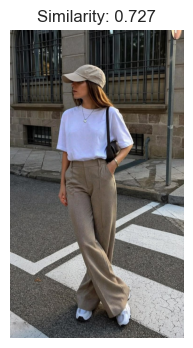

#outfits #fashion #summer #summerstyle.jpg --> Similarity: 0.712


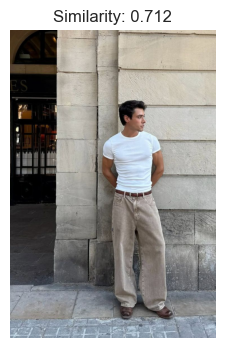

Korean Airport Outfit Inspo _ Streetwear Look.jpg --> Similarity: 0.701


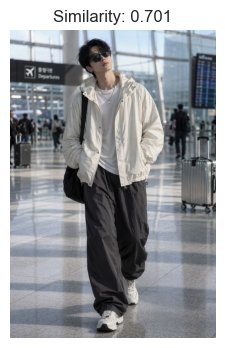

download (1).webp --> Similarity: 0.701


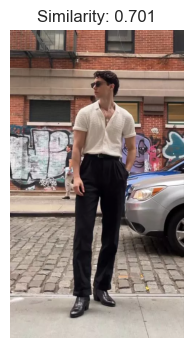

download (11).webp --> Similarity: 0.693


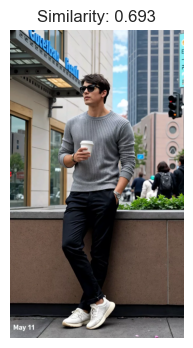

In [6]:
selected_image = r"C:\Users\ousama\Downloads\Fashion Color Analyzer\images\antonio medugno.jpg"

recommend_outfits(selected_image, top_n=5)